In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d":'true',
        "N": 2**28,
        "nx": 2**14,
        "ny": 2**14,
        "dx": 3.1e-10,
        "z_detector":4.8,
        "detector_size": 4e-4,
        "detector_size_y": 4e-4,
        "detector_pixel_size_x": 20e-6,
        "detector_pixel_size_y": 20e-6,
        "chunk_size": 2*1024 * 1024 * 1024 // 16,  # use 2048MB chunks
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [9900, 10100],
        "x_range": [-3e-6, 3e-6],
        "y_range": [-3e-6, 3e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        #"spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 0.8,
            "pixel_size_x": 5 * 1e-7,
            "pixel_size_y": 5 * 1e-7,
            "pixel_size_z": 5 * 1e-7,
            "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/sphere_grid.npy",
            "materials": [["Si", 2.33]],
            "x_positions":[0],
            "y_positions":[0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-04-13 10:14:28,585 INFO: Setting up simulation
2026-04-13 10:14:28,640 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/04/20260413_101428598892


1 1


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-04-13 10:14:28.791] [info] 3D mode:
[2026-04-13 10:14:28.791] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/04/20260413_101428598892/00000000
[2026-04-13 10:14:28.791] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-04-13 10:14:28.791] [info] GPU memory required for wavefield: 2048 MB
[2026-04-13 10:14:29.152] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-04-13 10:14:29.152] [info] Creating FFT for grid 16384x16384
[2026-04-13 10:14:29.186] [info] FFT created successfully
[2026-04-13 10:14:29.186] [info] [STEP 1] Initialization complete
[2026-04-13 10:14:29.186] [info] [STEP 2] Cutoff frequencies computed: fx=340539.2163600848, fy=340539.2163600848
[2026-04-13 10:14:29.186] [info] [STEP 3] Starting z position: 0.8
[2026-04-13 10:14:29.186] [info] [STEP 4] Setting up point source
[2026-04-13 10:14:29.186] [info] [STEP 5] Calling propagate_analytically_2d...
[2026-04-13 10:14:29.206] [info] [STEP 6] pr

[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit 

[2026-04-13 10:14:35.321] [info] [STEP 17] Sample applied successfully
[2026-04-13 10:14:35.321] [info] [STEP 18] Current z after element: 0.8000200000000001
[2026-04-13 10:14:35.321] [info] [STEP 19] Propagating remaining distance: 3.99998
[2026-04-13 10:14:35.321] [info]     [propagate_2d] START: dz=3.99998
[2026-04-13 10:14:35.321] [info]     [propagate_2d] END
[2026-04-13 10:14:35.321] [info] [STEP 20] Propagation completed
[2026-04-13 10:14:35.321] [info] [STEP 21] Finished optical elements processing
[2026-04-13 10:14:35.321] [info] [STEP 22] Final propagation to detector...
[2026-04-13 10:14:35.321] [info] [STEP 23] Final propagation done
[2026-04-13 10:14:35.321] [info] [STEP 24] Downsampling to detector...
[2026-04-13 10:14:35.321] [info]   nx=16384, ny=16384, nr_pixels_x=20, nr_pixels_y=20
[2026-04-13 10:14:35.321] [info]   d_detector_output = 0x809000000
[2026-04-13 10:14:35.321] [info]   detector_pixel_size_x=2e-05, detector_pixel_size_y=2e-05
[2026-04-13 10:14:35.321] [inf

[HOST] ENTER propagate_convolve_step_2d
[HOST] Exit propagate_convolve_step_2d
100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [02:45<00:00, 165.93s/it]

[2026-04-13 10:17:14.425] [info] [STEP 27] Copy done
[2026-04-13 10:17:14.425] [info] [STEP 28] Saving detector output...
[2026-04-13 10:17:14.435] [info] [STEP 29] Save done
[2026-04-13 10:17:14.476] [info] 2D Simulation finished in 178.80959216 seconds


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 20 20


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

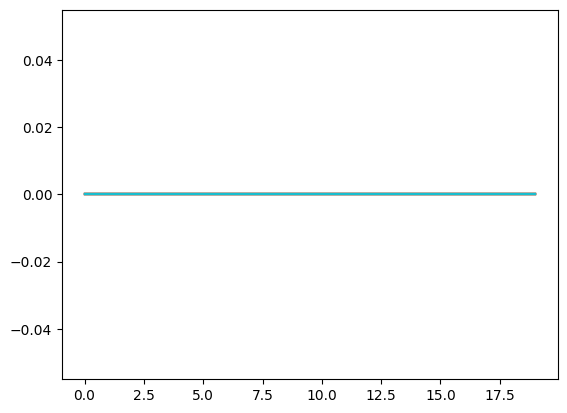

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

## History

To see the interference pattern in empty space, we can record slices throughout the simulation and then plot them. `run_single_simulation` takes an optional argument `history_dz` defining the resolution with which we record the history.

Note that the history is not necessarily recorded with a constant z-spacing. Inside gratings and samples, one slice is recorded for every step. The history also records a list of z-coordinates at which the slices were recorded, which we can use for plotting.

In [ ]:
multisim.run_single_simulation(sim_path, 1, scratch_dir, save_keypoints_path=None, history_dz=0.02)

In [ ]:
# Path to the directory for the source with index 1
source_dir = multisim.get_sub_dir(sim_path, 1)

hist_x = np.load(source_dir / "history_x.npy")
hist_z = np.load(source_dir / "history_z.npy")
hist = np.load(source_dir / "history.npy")
plt.pcolormesh(
    hist_z,
    hist_x,
    hist,
    cmap="Greys_r",
    vmin=0,
    vmax=1e-6,
    shading="nearest",
)
plt.xlabel("z (m)")
plt.ylabel("x (m)")